# 2. Simple Programming and Exploratory Analytics
2.1 Images

In [6]:
import torch
from torch.utils.data import Subset
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange

# For 3D plot
from mpl_toolkits.mplot3d import Axes3D  

In [7]:
# Task 1
# Download MNIST (train split) using torchvision
mnist_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()  
)

# Create a subset of exactly 1000 samples
subset_size = 1000
subset_indices = list(range(subset_size)) 
mnist_subset = Subset(mnist_train, subset_indices)

print("Subset length:", len(mnist_subset))

# Peek one sample
img0, label0 = mnist_subset[0]
print("Single sample image shape:", img0.shape, "label:", label0)

100.0%
100.0%
100.0%
100.0%

Subset length: 1000
Single sample image shape: torch.Size([1, 28, 28]) label: 5


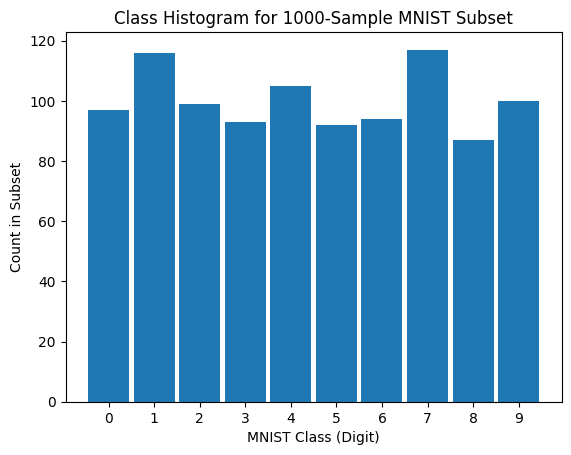

In [8]:
# Task 2
# Collect labels
labels = [mnist_subset[i][1] for i in range(len(mnist_subset))]

plt.figure()
plt.hist(labels, bins=np.arange(11)-0.5, rwidth=0.9)
plt.xticks(range(10))
plt.xlabel("MNIST Class (Digit)")
plt.ylabel("Count in Subset")
plt.title("Class Histogram for 1000-Sample MNIST Subset")
plt.show()

In [9]:
images = torch.stack([mnist_subset[i][0].squeeze(0) for i in range(len(mnist_subset))])  # [1000,28,28]

print("images shape:", images.shape)  # should be [1000,28,28]
batch_size = 25

# Safety check: ensure divisible
assert images.shape[0] % batch_size == 0, "1000 must be divisible by batch_size"

# Rearrange: (num_samples, H, W) - (num_batches, batch_size, 1, H, W)
batched_images = rearrange(images, '(b n) h w -> b n 1 h w', n=batch_size)

print("batched_images shape:", batched_images.shape)  

images shape: torch.Size([1000, 28, 28])
batched_images shape: torch.Size([40, 25, 1, 28, 28])


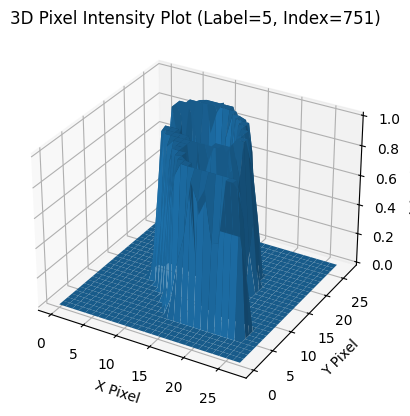

In [10]:
# Pick random index in subset
rand_idx = np.random.randint(0, len(mnist_subset))
img, label = mnist_subset[rand_idx]  # img is [1,28,28]

# Convert to [28,28] for plotting
img_2d = img.squeeze(0).numpy()

H, W = img_2d.shape
x = np.arange(W)
y = np.arange(H)
X, Y = np.meshgrid(x, y)   # X and Y are [28,28]
Z = img_2d                 # intensities [28,28] in [0,1]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Surface plot
ax.plot_surface(X, Y, Z)

ax.set_title(f"3D Pixel Intensity Plot (Label={label}, Index={rand_idx})")
ax.set_xlabel("X Pixel")
ax.set_ylabel("Y Pixel")
ax.set_zlabel("Intensity")
plt.show()

2.2 Time Series

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("energydata_complete.csv")

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Set as index (important for time series)
df.set_index('date', inplace=True)

print(df.head())

                     Appliances  lights     T1       RH_1    T2       RH_2  \
date                                                                         
2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

                        T3       RH_3         T4       RH_4  ...         T9  \
date                                                         ...              
2016-01-11 17:00:00  19.79  44.730000  19.000000  45.566667  ...  17.033333   
2016-01-11 17:10:00  19.79  44.790000  19.000000  45.992500  ...  17.066667   
2016-01-11 17:20:00  19.79  44.933333  18.926667  45.890000  ...  17.000000   
2016-01-11 17:30:00  19.79  45.000000  18.890000  45.72333

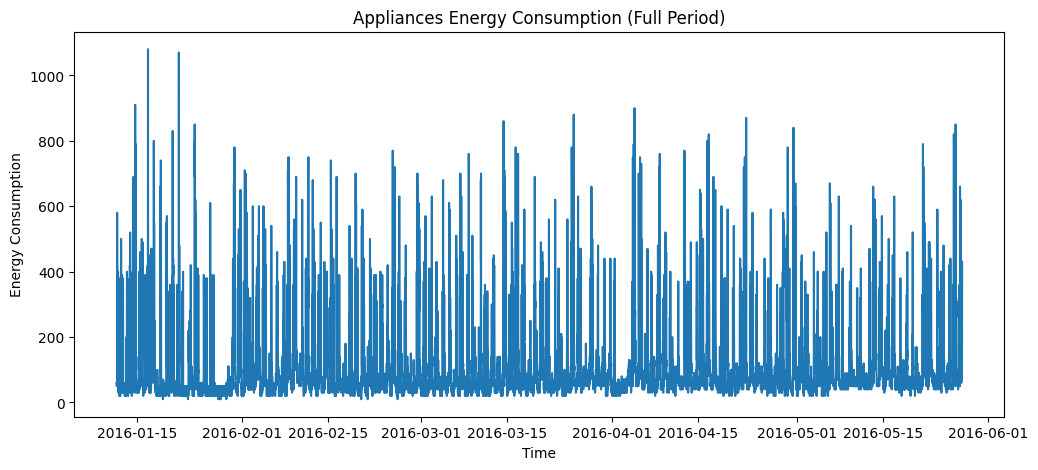

In [14]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Appliances'])
plt.title("Appliances Energy Consumption (Full Period)")
plt.xlabel("Time")
plt.ylabel("Energy Consumption")
plt.show()

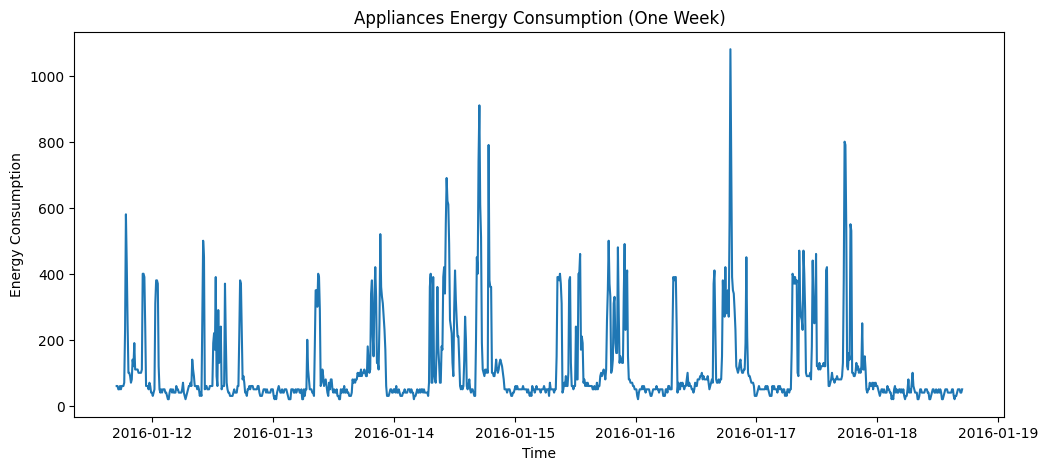

In [15]:
# Pick any week
one_week = df.iloc[:7*24*6]  # 7 days * 24 hrs * 6 (10-min intervals)

plt.figure(figsize=(12,5))
plt.plot(one_week.index, one_week['Appliances'])
plt.title("Appliances Energy Consumption (One Week)")
plt.xlabel("Time")
plt.ylabel("Energy Consumption")
plt.show()

/tmp/ipykernel_106750/172721123.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = weekly['Appliances'].resample('H').mean()


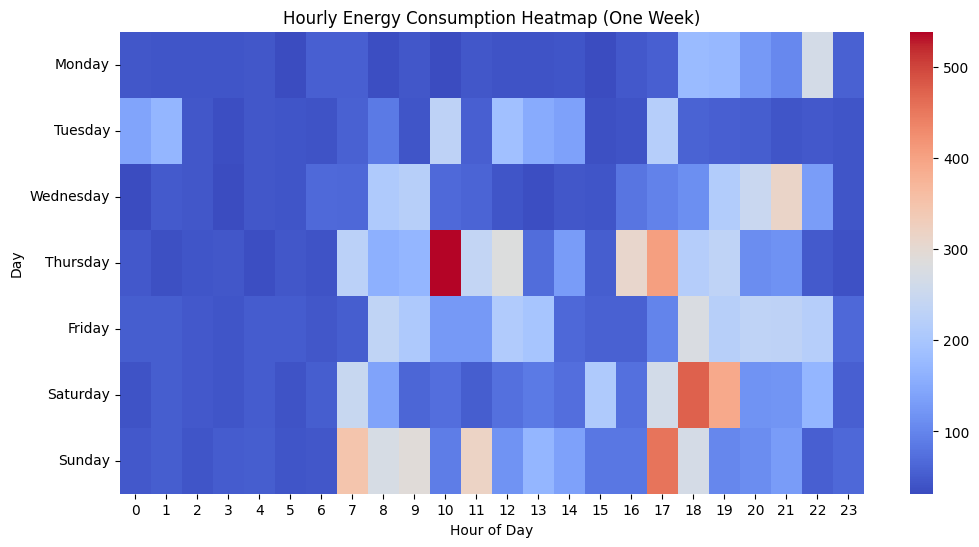

In [17]:
weekly = df.iloc[:7*24*6]

hourly = weekly['Appliances'].resample('H').mean()

# Create day & hour columns
heatmap_df = hourly.to_frame()
heatmap_df['day'] = heatmap_df.index.day_name()
heatmap_df['hour'] = heatmap_df.index.hour

# Pivot table
pivot_table = heatmap_df.pivot(index='day', columns='hour', values='Appliances')

# Order days properly
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot_table = pivot_table.reindex(day_order)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, cmap='coolwarm')
plt.title("Hourly Energy Consumption Heatmap (One Week)")
plt.xlabel("Hour of Day")
plt.ylabel("Day")
plt.show()

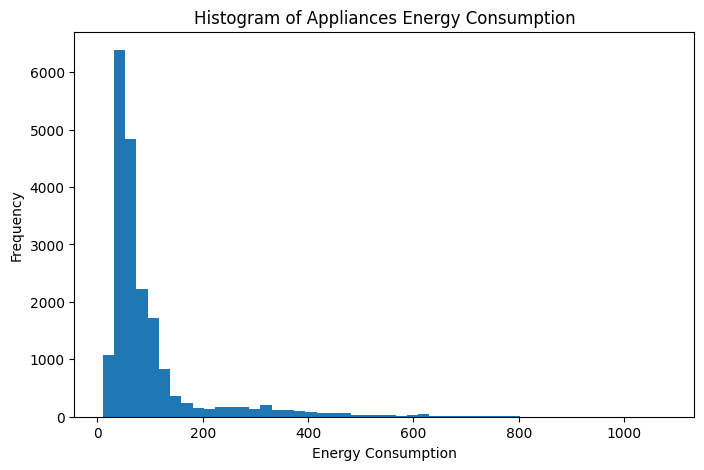

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df['Appliances'], bins=50)
plt.title("Histogram of Appliances Energy Consumption")
plt.xlabel("Energy Consumption")
plt.ylabel("Frequency")
plt.show()

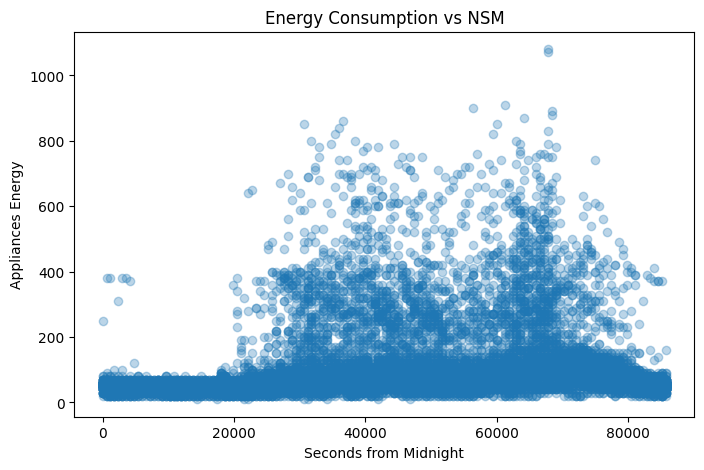

In [19]:
df['NSM'] = df.index.hour*3600 + df.index.minute*60 + df.index.second
plt.figure(figsize=(8,5))
plt.scatter(df['NSM'], df['Appliances'], alpha=0.3)
plt.title("Energy Consumption vs NSM")
plt.xlabel("Seconds from Midnight")
plt.ylabel("Appliances Energy")
plt.show()

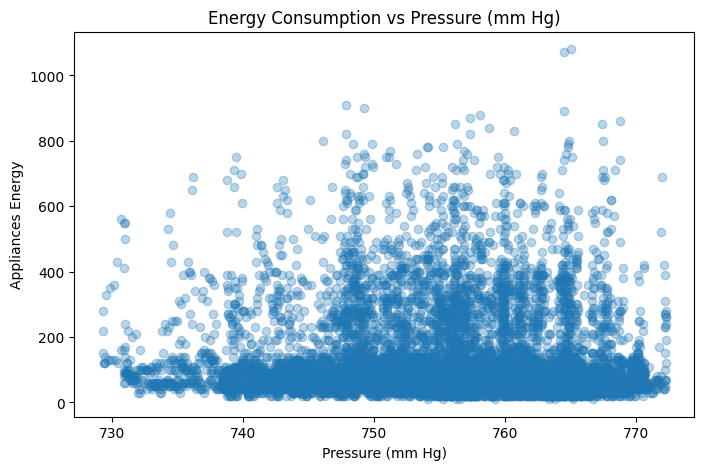

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(df['Press_mm_hg'], df['Appliances'], alpha=0.3)
plt.title("Energy Consumption vs Pressure (mm Hg)")
plt.xlabel("Pressure (mm Hg)")
plt.ylabel("Appliances Energy")
plt.show()

2.3 Multi-variate

In [22]:
import pandas as pd
import numpy as np

# Load dataset
# Replace with your actual file name if needed
df = pd.read_csv("/home/sanjitap/projects/personal/me5920/hw1/airfoil+self+noise/airfoil_self_noise.dat", sep="\t", header=None)

# Assign column names (important for clarity)
df.columns = [
    "Frequency",
    "Angle_of_attack",
    "Chord_length",
    "Velocity",
    "Displacement_thickness",
    "Sound_pressure_level"
]

print(df.head())

   Frequency  Angle_of_attack  Chord_length  Velocity  Displacement_thickness  \
0        800              0.0        0.3048      71.3                0.002663   
1       1000              0.0        0.3048      71.3                0.002663   
2       1250              0.0        0.3048      71.3                0.002663   
3       1600              0.0        0.3048      71.3                0.002663   
4       2000              0.0        0.3048      71.3                0.002663   

   Sound_pressure_level  
0               126.201  
1               125.201  
2               125.951  
3               127.591  
4               127.461  


In [23]:
mean_values = df.mean()
print("Mean:\n", mean_values)

Mean:
 Frequency                 2886.380572
Angle_of_attack              6.782302
Chord_length                 0.136548
Velocity                    50.860745
Displacement_thickness       0.011140
Sound_pressure_level       124.835943
dtype: float64


In [24]:
variance_values = df.var()
std_values = df.std()

print("\nVariance:\n", variance_values)
print("\nStandard Deviation:\n", std_values)


Variance:
 Frequency                 9.938717e+06
Angle_of_attack           3.502424e+01
Chord_length              8.749868e-03
Velocity                  2.425116e+02
Displacement_thickness    1.729287e-04
Sound_pressure_level      4.759146e+01
dtype: float64

Standard Deviation:
 Frequency                 3152.573137
Angle_of_attack              5.918128
Chord_length                 0.093541
Velocity                    15.572784
Displacement_thickness       0.013150
Sound_pressure_level         6.898657
dtype: float64


In [25]:
median_values = df.median()
print("\nMedian:\n", median_values)


Median:
 Frequency                 1600.000000
Angle_of_attack              5.400000
Chord_length                 0.101600
Velocity                    39.600000
Displacement_thickness       0.004957
Sound_pressure_level       125.721000
dtype: float64


In [26]:
kurtosis_values = df.kurtosis()
print("\nKurtosis:\n", kurtosis_values)


Kurtosis:
 Frequency                 5.708685
Angle_of_attack          -0.412951
Chord_length             -1.037964
Velocity                 -1.563951
Displacement_thickness    2.218903
Sound_pressure_level     -0.314187
dtype: float64


In [27]:
skewness_values = df.skew()
print("\nSkewness:\n", skewness_values)


Skewness:
 Frequency                 2.137084
Angle_of_attack           0.689164
Chord_length              0.457457
Velocity                  0.235852
Displacement_thickness    1.702165
Sound_pressure_level     -0.418952
dtype: float64


In [28]:
range_values = df.max() - df.min()
print("\nRange:\n", range_values)


Range:
 Frequency                 19800.000000
Angle_of_attack              22.200000
Chord_length                  0.279400
Velocity                     39.600000
Displacement_thickness        0.058011
Sound_pressure_level         37.607000
dtype: float64


In [29]:
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Variance": df.var(),
    "Std Dev": df.std(),
    "Median": df.median(),
    "Kurtosis": df.kurtosis(),
    "Skewness": df.skew(),
    "Range": df.max() - df.min()
})

print("\nSummary Statistics:\n")
print(summary)


Summary Statistics:

                               Mean      Variance      Std Dev       Median  \
Frequency               2886.380572  9.938717e+06  3152.573137  1600.000000   
Angle_of_attack            6.782302  3.502424e+01     5.918128     5.400000   
Chord_length               0.136548  8.749868e-03     0.093541     0.101600   
Velocity                  50.860745  2.425116e+02    15.572784    39.600000   
Displacement_thickness     0.011140  1.729287e-04     0.013150     0.004957   
Sound_pressure_level     124.835943  4.759146e+01     6.898657   125.721000   

                        Kurtosis  Skewness         Range  
Frequency               5.708685  2.137084  19800.000000  
Angle_of_attack        -0.412951  0.689164     22.200000  
Chord_length           -1.037964  0.457457      0.279400  
Velocity               -1.563951  0.235852     39.600000  
Displacement_thickness  2.218903  1.702165      0.058011  
Sound_pressure_level   -0.314187 -0.418952     37.607000  
